In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import open_clip
from PIL import Image
import json
import os
from tqdm.notebook import tqdm
import open_clip
import random

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device: ", device)

Using device:  cuda


In [ ]:
model, _, preprocess = open_clip.create_model_and_transforms('ViT-B-32', pretrained='laion2b_s34b_b79k')
model.to(device)

CLIP(
  (visual): VisionTransformer(
    (conv1): Conv2d(3, 768, kernel_size=(32, 32), stride=(32, 32), bias=False)
    (patch_dropout): Identity()
    (ln_pre): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
    (transformer): Transformer(
      (resblocks): ModuleList(
        (0-11): 12 x ResidualAttentionBlock(
          (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
          )
          (ls_1): Identity()
          (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (mlp): Sequential(
            (c_fc): Linear(in_features=768, out_features=3072, bias=True)
            (gelu): GELU(approximate='none')
            (c_proj): Linear(in_features=3072, out_features=768, bias=True)
          )
          (ls_2): Identity()
        )
      )
    )
    (ln_post): LayerNorm((768,), eps=1e-05, elementwise_affine

In [ ]:
tokenizer = open_clip.get_tokenizer('ViT-B-32')

In [ ]:
# One random caption per image

In [ ]:
img_dir = '/home/ehath390/Desktop/DeepLearningDatatset/RSICD_images/'
json_dir = '/home/ehath390/Desktop/DeepLearningDatatset/dataset_rsicd.json'

class RSCID_Dataset():
    def __init__(self, img_dir, json_path, preprocess, tokenizer, split='val'):
        self.img_dir = img_dir
        self.preprocess = preprocess
        self.tokenizer = tokenizer
        self.data = []

        with open(json_path, 'r') as f:
            annotations = json.load(f)

        for item in annotations['images']:
            if item['split'] == split:
                captions = [c['raw'] for c in item['sentences']]
                self.data.append({
                    'image_path': os.path.join(img_dir, item['filename']),
                    'captions': captions
                })
        print(f"Loaded {len(self.data)} items for split: {split}")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image = Image.open(item['image_path']).convert('RGB')
        image = self.preprocess(image)

        caption = random.choice(item['captions'])
        text = self.tokenizer(caption)

        return image, text

splitb_dataset = RSCID_Dataset(img_dir, json_dir, preprocess, tokenizer, split='val')


Loaded 1094 items for split: val


In [ ]:
# Same image replicated five times with it's five different captions

In [ ]:
img_dir = '/home/ehath390/Desktop/DeepLearningDatatset/RSICD_images/'
json_dir = '/home/ehath390/Desktop/DeepLearningDatatset/dataset_rsicd.json'

class RSCID_Dataset():
    def __init__(self, img_dir, json_path, preprocess, tokenizer, split='val', use_all_captions=True):
        self.img_dir = img_dir
        self.preprocess = preprocess
        self.tokenizer = tokenizer
        self.data = []

        with open(json_path, 'r') as f:
            annotations = json.load(f)

        for item in annotations['images']:
            if item['split'] != split:
                continue

            image_path = os.path.join(img_dir, item['filename'])
            captions = [c['raw'] for c in item['sentences']]

            if use_all_captions:
                for caption in captions:
                    self.data.append({
                        'image_path': image_path,
                        'caption': caption
                    })
            else:
                self.data.append({
                    'image_path': image_path,
                    'captions': captions
                })

        print(f"Loaded {len(self.data)} image-text pairs for split: {split}")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image = Image.open(item['image_path']).convert('RGB')
        image = self.preprocess(image)
        text = self.tokenizer(item['caption'])

        return image, text

splitb_dataset = RSCID_Dataset(img_dir, json_dir, preprocess, tokenizer, split='val')

Loaded 5470 image-text pairs for split: val


In [ ]:
train_ratio = 0.8
test_ratio = 0.2

dataset_size = len(splitb_dataset)
train_size = int(dataset_size * train_ratio)
val_size = dataset_size - train_size

train_dataset, val_dataset = torch.utils.data.random_split(splitb_dataset, [train_size, val_size])
batch_size = 32
train_dataloader = DataLoader(train_dataset, batch_size, shuffle=True, num_workers=2)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"Training dataset of split B: {len(train_dataloader)}")
print(f"Validation dataset of split B: {len(val_dataloader)}")


Training dataset of split B: 137
Validation dataset of split B: 35


In [ ]:
import torch
import torch.nn.functional as F

def contrastive_loss(image_features, text_features, logit_scale):
    logits_per_image = logit_scale * image_features @ text_features.T
    logits_per_text = logit_scale * text_features @ image_features.T

    labels = torch.arange(len(logits_per_image), device=device)

    loss_i = torch.nn.functional.cross_entropy(logits_per_image, labels)
    loss_t = torch.nn.functional.cross_entropy(logits_per_text, labels)

    loss = (loss_i + loss_t) / 2
    return loss

### Contrastive Loss (CLIP-style) Equation

Given a batch of `B` image-text pairs, where `image_features` and `text_features` are the normalized embeddings for images and texts respectively, and `logit_scale` is a learnable temperature parameter, the contrastive loss is calculated as follows:

For `logits_per_image` (image-to-text similarity):

$L_{i} = -\frac{1}{B} \sum_{j=1}^{B} \log \frac{\exp(\text{image_features}_j \cdot \text{text_features}_j \cdot \tau)}{\sum_{k=1}^{B} \exp(\text{image_features}_j \cdot \text{text_features}_k \cdot \tau)}$

For `logits_per_text` (text-to-image similarity):

$L_{t} = -\frac{1}{B} \sum_{j=1}^{B} \log \frac{\exp(\text{text_features}_j \cdot \text{image_features}_j \cdot \tau)}{\sum_{k=1}^{B} \exp(\text{text_features}_j \cdot \text{image_features}_k \cdot \tau)}$

Where:
- $\tau$ is the `logit_scale` (temperature parameter).
- $\text{image_features}_j \cdot \text{text_features}_k$ represents the dot product (cosine similarity) between image $j$ and text $k$.

The total contrastive loss is the average of these two losses:

$L_{contrastive} = \frac{L_i + L_t}{2}$

In [ ]:
from peft import LoraConfig, get_peft_model, TaskType
config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules = ["c_fc", "c_proj", "out_proj"],
    lora_dropout=0.1,
    bias="none",
    task_type=TaskType.FEATURE_EXTRACTION
)

In [ ]:
peft_model = get_peft_model(model, config)

In [ ]:
peft_model.print_trainable_parameters()

trainable params: 2,949,120 || all params: 154,226,433 || trainable%: 1.9122


In [ ]:
peft_model.to(device)

PeftModelForFeatureExtraction(
  (base_model): LoraModel(
    (model): CLIP(
      (visual): VisionTransformer(
        (conv1): Conv2d(3, 768, kernel_size=(32, 32), stride=(32, 32), bias=False)
        (patch_dropout): Identity()
        (ln_pre): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (transformer): Transformer(
          (resblocks): ModuleList(
            (0-11): 12 x ResidualAttentionBlock(
              (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
              (attn): MultiheadAttention(
                (out_proj): lora.Linear(
                  (base_layer): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
                  (lora_dropout): ModuleDict(
                    (default): Dropout(p=0.1, inplace=False)
                  )
                  (lora_A): ModuleDict(
                    (default): Linear(in_features=768, out_features=16, bias=False)
                  )
                  (lora_B): ModuleDic

In [ ]:
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, peft_model.parameters()),
    lr=1e-4,
    weight_decay=0.01
)

In [ ]:
num_epochs = 20
from torch.optim.lr_scheduler import CosineAnnealingLR
scheduler = CosineAnnealingLR(optimizer, T_max=num_epochs)

In [ ]:
num_epochs = 20

for epoch in range(num_epochs):
    peft_model.train()
    total_train_loss = 0
    train_progress_bar = tqdm(train_dataloader, desc=f"Epoch {epoch+1} Training")

    for batch_idx, (images, texts) in enumerate(train_progress_bar):
        images = images.to(device)
        texts = texts.squeeze(1).to(device)

        optimizer.zero_grad()

        image_features = peft_model.encode_image(images)
        text_features = peft_model.encode_text(texts)

        image_features = image_features / image_features.norm(dim=-1, keepdim=True)
        text_features = text_features / text_features.norm(dim=-1, keepdim=True)

        logit_scale = peft_model.logit_scale.exp().clamp(max=100)

        loss = contrastive_loss(image_features, text_features, logit_scale)

        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()
        train_progress_bar.set_postfix(loss=loss.item())

    scheduler.step()

    avg_train_loss = total_train_loss / len(train_dataloader)
    print(f"Epoch {epoch+1} | Average Train Loss: {avg_train_loss:.4f}")

    peft_model.eval()
    total_val_loss = 0
    val_progress_bar = tqdm(val_dataloader, desc=f"Epoch {epoch+1} Validation")

    with torch.no_grad():
        for batch_idx, (images, texts) in enumerate(val_progress_bar):
            images = images.to(device)
            texts = texts.squeeze(1).to(device)

            image_features = peft_model.encode_image(images)
            text_features = peft_model.encode_text(texts)

            image_features = image_features / image_features.norm(dim=-1, keepdim=True)
            text_features = text_features / text_features.norm(dim=-1, keepdim=True)

            logit_scale = peft_model.logit_scale.exp().clamp(max=100)

            loss = contrastive_loss(image_features, text_features, logit_scale)

            total_val_loss += loss.item()
            val_progress_bar.set_postfix(loss=loss.item())

    avg_val_loss = total_val_loss / len(val_dataloader)
    print(f"Epoch {epoch+1} | Average Validation Loss: {avg_val_loss:.4f}")

print("LoRA Finetuning complete!")

Epoch 1 Training:   0%|          | 0/137 [00:00<?, ?it/s]

Epoch 1 | Average Train Loss: 1.1269


Epoch 1 Validation:   0%|          | 0/35 [00:00<?, ?it/s]

Epoch 1 | Average Validation Loss: 0.7731


Epoch 2 Training:   0%|          | 0/137 [00:00<?, ?it/s]

...

Epoch 19 | Average Validation Loss: 0.6022


Epoch 20 Training:   0%|          | 0/137 [00:00<?, ?it/s]

Epoch 20 | Average Train Loss: 0.0925


Epoch 20 Validation:   0%|          | 0/35 [00:00<?, ?it/s]

Epoch 20 | Average Validation Loss: 0.6026
LoRA Finetuning complete!


In [ ]:
# zero shot classification aftert this

In [ ]:
folder = '/home/ehath390/Desktop/DeepLearningDatatset/txtclasses_rsicd/'
classes = []
for filename in sorted(os.listdir(folder)):
    if filename.endswith('.txt'):
        class_name = filename.replace('.txt', '')
        classes.append(class_name)

print(f"Found {len(classes)} classes: {classes}")

Found 31 classes: ['Airport', 'BareLand', 'BaseballField', 'Beach', 'Bridge', 'Center', 'Church', 'Commercial', 'DenseResidential', 'Desert', 'Farmland', 'Forest', 'Industrial', 'Meadow', 'MediumResidential', 'Mountain', 'Park', 'Parking', 'Playground', 'Pond', 'Port', 'RailwayStation', 'Resort', 'River', 'School', 'SparseResidential', 'Square', 'Stadium', 'StorageTanks', 'Viaduct', 'playfields']


In [ ]:
class RSICD_TestDataset(Dataset):
    def __init__(self, img_dir, json_path, preprocess, split='test'):
        self.img_dir = img_dir
        self.preprocess = preprocess
        self.data = []

        with open(json_path, 'r') as f:
            annotations = json.load(f)

        for item in annotations['images']:
            if item['split'] == split:
                self.data.append({
                    'image_path': os.path.join(img_dir, item['filename']),
                    'filename': item['filename']
                })

        print(f"Loaded {len(self.data)} test images")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image = Image.open(item['image_path']).convert('RGB')
        image = self.preprocess(image)
        return image, item['filename']

test_dataset = RSICD_TestDataset(img_dir, json_dir, preprocess, split='test')
test_dataloader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2)

Loaded 1093 test images


In [ ]:
templates = [
    "A satellite image of {}.",
    "An aerial image of {}.",
    "A remote sensing image of {}.",
    "An overhead view of {}.",
]

peft_model.eval()

with torch.no_grad():
    class_embeddings = []
    for cls in classes:
        prompts = [t.format(cls) for t in templates]
        tokens = tokenizer(prompts).to(device)
        embs = peft_model.encode_text(tokens)
        embs = embs / embs.norm(dim=-1, keepdim=True)
        avg_emb = embs.mean(dim=0)
        avg_emb = avg_emb / avg_emb.norm()
        class_embeddings.append(avg_emb)

    class_embeddings = torch.stack(class_embeddings)
    print(f"Class embedding matrix: {class_embeddings.shape}")

Class embedding matrix: torch.Size([31, 512])


In [ ]:
all_preds = []
all_filenames = []

with torch.no_grad():
    for images, filenames in tqdm(test_dataloader, desc="Zero-shot classification"):
        images = images.to(device)

        image_features = peft_model.encode_image(images)
        image_features = image_features / image_features.norm(dim=-1, keepdim=True)

        similarity = image_features @ class_embeddings.T
        predictions = similarity.argmax(dim=-1)

        all_preds.extend([classes[p] for p in predictions.cpu()])
        all_filenames.extend(filenames)

print("Classification done!")

Zero-shot classification:   0%|          | 0/18 [00:00<?, ?it/s]

Classification done!


In [ ]:
filename_to_class = {}
folder = '/home/ehath390/Desktop/DeepLearningDatatset/txtclasses_rsicd/'

for txt_file in sorted(os.listdir(folder)):
    if txt_file.endswith('.txt'):
        class_name = txt_file.replace('.txt', '')
        with open(os.path.join(folder, txt_file), 'r') as f:
            for line in f:
                image_filename = line.strip()
                if image_filename:
                    filename_to_class[image_filename] = class_name

print(f"Mapped {len(filename_to_class)} images to classes")

all_gt = [filename_to_class[fname] for fname in all_filenames]

Mapped 10921 images to classes


Zero-shot Accuracy: 75.11%
Macro F1 Score:     0.7486


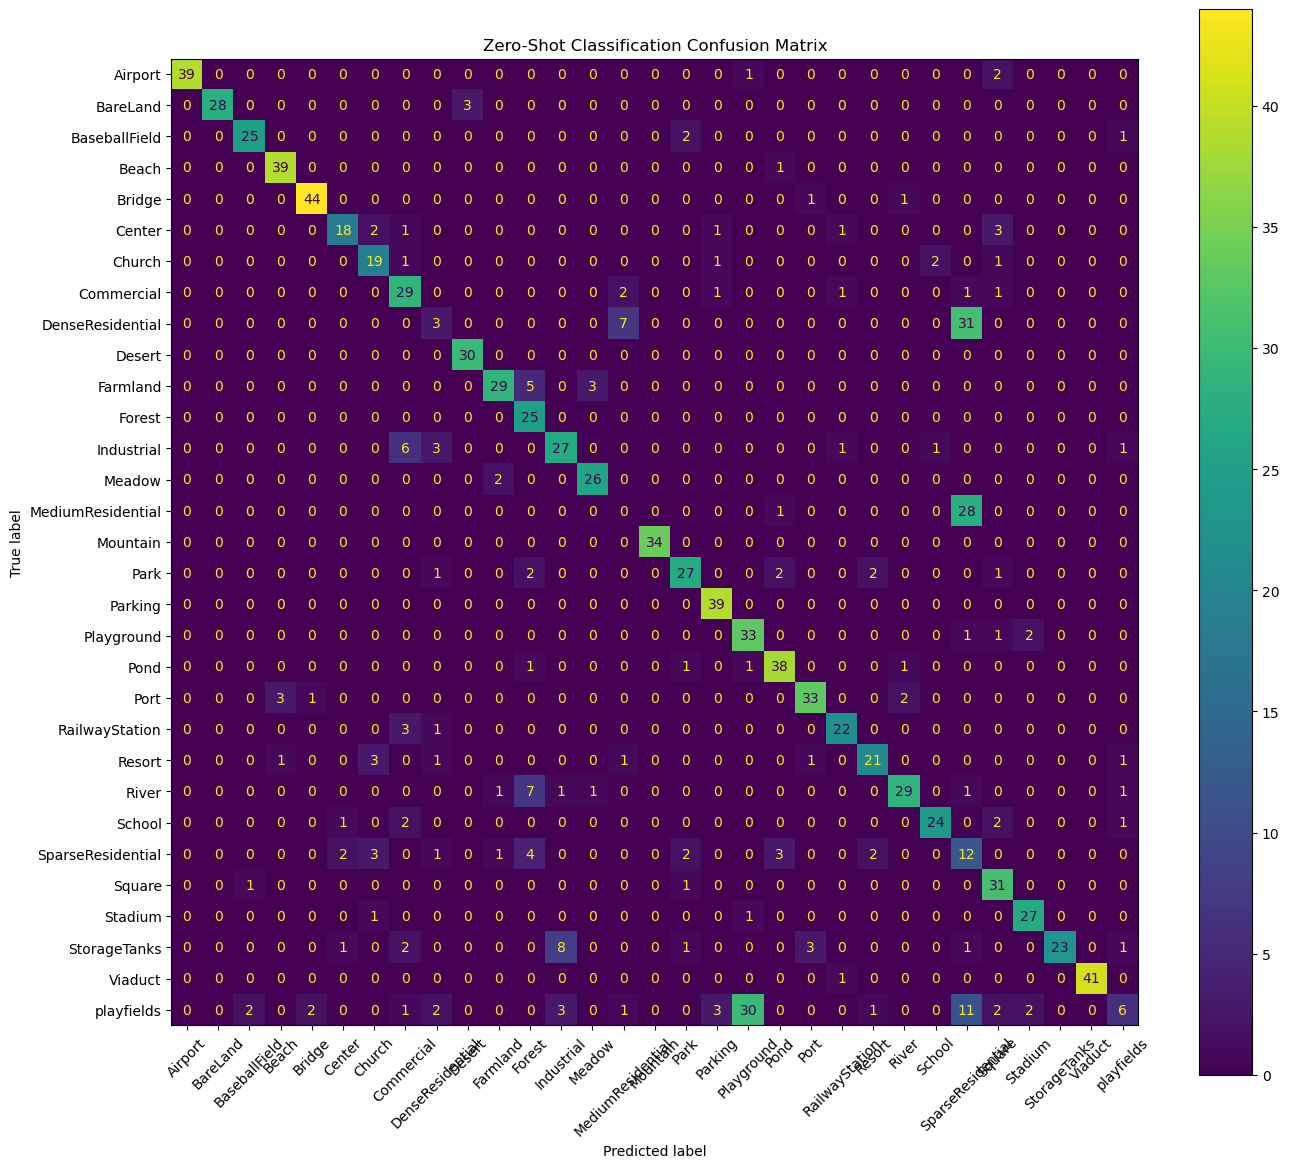

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

accuracy = accuracy_score(all_gt, all_preds)
f1 = f1_score(all_gt, all_preds, average='macro')

print(f"Zero-shot Accuracy: {accuracy * 100:.2f}%")
print(f"Macro F1 Score:     {f1:.4f}")


cm = confusion_matrix(all_gt, all_preds, labels=classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)

fig, ax = plt.subplots(figsize=(14, 12))
disp.plot(ax=ax, xticks_rotation=45, colorbar=True)
plt.title("Zero-Shot Classification Confusion Matrix")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

In [ ]:
# SimCLR for semi supervised finetuning

Image (Split A) → Augmentation 1 → image_features_1 ─┐
                                                        ├→ Push together (same image)
Image (Split A) → Augmentation 2 → image_features_2 ─┘

In [ ]:
from torchvision import transforms

augmentation = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.5, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(0.4, 0.4, 0.4, 0.1),
    transforms.RandomGrayscale(p=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.48145466, 0.4578275, 0.40821073], std=[0.26862954, 0.26130258, 0.27577711])
])

In [ ]:
img_dir = '/home/ehath390/Desktop/DeepLearningDatatset/RSICD_images/'
json_dir = '/home/ehath390/Desktop/DeepLearningDatatset/dataset_rsicd.json'

class RSCID_Dataset():
    def __init__(self, img_dir, json_path, augmentation):
        self.img_dir = img_dir
        self.augmentation = augmentation
        self.images = []

        with open(json_path, 'r') as f:
            annotations = json.load(f)

        for item in annotations['images']:
            if item['split'] == 'train':
                self.images.append(os.path.join(img_dir, item['filename']))
        print(f"Loaded {len(self.images)} items for split: A")

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        item = self.images[idx]
        image = Image.open(item).convert('RGB')
        view1 = self.augmentation(image)
        view2 = self.augmentation(image)

        return view1, view2

In [ ]:
splitA_dataset = RSCID_Dataset(img_dir, json_dir, augmentation)

Loaded 8734 items for split: A


In [ ]:
batch_size = 32
split_A_loader = DataLoader(splitA_dataset, batch_size=batch_size, shuffle=True, num_workers=2,drop_last=True)

In [ ]:
# Loss function

In [ ]:
def self_supervised_loss(features1, features2, temperature=0.07):
    features = torch.cat([features1, features2], dim=0)
    features = torch.nn.functional.normalize(features, dim=1)

    similarity = torch.matmul(features, features.T) / temperature
    B = features1.shape[0]

    mask = torch.eye(2 * B, device=features.device).bool()
    sim_matrix_masked = similarity.masked_fill(mask, float('-inf'))

    labels = torch.cat([
        torch.arange(B, 2 * B),
        torch.arange(0, B)
    ]).to(features.device)

    loss = F.cross_entropy(sim_matrix_masked, labels)
    return loss

### InfoNCE Loss for Self-Supervised Fine-Tuning (SimCLR-style) Equation

Given two augmented views of the same image, `features1` and `features2` (normalized embeddings), and a `temperature` parameter, the self-supervised loss is calculated as follows:

Let $z_i$ and $z_j$ be the normalized embeddings of two augmented views of the same image. For a batch size `B`, we have $2B$ total features (B pairs). We concatenate `features1` and `features2` to form a tensor `features` of shape `(2B, D)`, where `D` is the embedding dimension.

The similarity matrix $S$ is computed as:

$S_{mn} = \frac{\text{features}_m \cdot \text{features}_n}{\text{temperature}}$

For each positive pair $(i, j)$ (where $i$ and $j$ are indices of two augmented views of the same original image, and $m$ is the index in the concatenated `features` tensor), the loss is:

$L_{ij} = -\log \frac{\exp(S_{ij})}{\sum_{k \in A(i)} \exp(S_{ik})}$

Where:
- $A(i)$ is the set of all indices in the batch except $i$.
- The sum $\sum_{k \in A(i)} \exp(S_{ik})$ represents the sum of similarities to all other samples in the batch (including the other augmented view of the same image, which is the positive sample, and $2B-2$ negative samples).

The final loss for the batch is the average over all positive pairs:

$L_{self-supervised} = \frac{1}{2B} \sum_{m=1}^{2B} L_m$

In the provided code, `labels` are constructed to align the positive pairs, and `mask` is used to exclude self-similarity ($S_{ii}$) from the denominator sum.

In [ ]:
# training

In [ ]:
from torch.cuda.amp import autocast, GradScaler
scaler = GradScaler()

# ── 1. Fresh model for semi-supervised (never reuse the supervised peft_model) ──
model_semisup, _, _ = open_clip.create_model_and_transforms('ViT-B-32', pretrained='laion2b_s34b_b79k')
model_semisup.to(device)

peft_model_semisup = get_peft_model(model_semisup, config).to(device)
peft_model_semisup.print_trainable_parameters()

optimizer_semisup = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, peft_model_semisup.parameters()),
    lr=1e-5,
    weight_decay=0.01
)

# ── 2. Hyperparameters ──
lambda_unsup = 0.5
num_epochs   = 5

scheduler_semisup = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_semisup, T_max=num_epochs
)

# ── 3. Cycle Split B (small) so it keeps up with Split A (large) ──
from itertools import cycle
split_b_iter = cycle(train_dataloader)   # 14 batches cycled repeatedly

# ── 4. Training loop driven by Split A (136 batches per epoch) ──
for epoch in range(num_epochs):
    peft_model_semisup.train()
    total_loss = total_loss_sup = total_loss_unsup = 0.0

    for view1, view2 in tqdm(split_A_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):

        images_b, texts_b = next(split_b_iter)
        images_b = images_b.to(device)
        texts_b  = texts_b.squeeze(1).to(device)
        view1    = view1.to(device)
        view2    = view2.to(device)

        optimizer_semisup.zero_grad()

        with autocast():    # ← runs forward pass in float16
            # Supervised loss
            img_feat_b = F.normalize(peft_model_semisup.encode_image(images_b), dim=-1)
            txt_feat_b = F.normalize(peft_model_semisup.encode_text(texts_b), dim=-1)
            logit_scale = peft_model_semisup.logit_scale.exp().clamp(max=100)
            loss_sup = contrastive_loss(img_feat_b, txt_feat_b, logit_scale)

            # Unsupervised loss
            feat1 = F.normalize(peft_model_semisup.encode_image(view1), dim=-1)
            feat2 = F.normalize(peft_model_semisup.encode_image(view2), dim=-1)
            loss_unsup = self_supervised_loss(feat1, feat2)

            loss = loss_sup + lambda_unsup * loss_unsup

        # Scaled backward pass
        scaler.scale(loss).backward()
        scaler.step(optimizer_semisup)
        scaler.update()

        total_loss       += loss.item()
        total_loss_sup   += loss_sup.item()
        total_loss_unsup += loss_unsup.item()

    scheduler_semisup.step()
    torch.cuda.empty_cache()
    n = len(split_A_loader)
    print(f"Epoch {epoch+1}/{num_epochs} | "
          f"Total: {total_loss/n:.4f} | "
          f"Sup: {total_loss_sup/n:.4f} | "
          f"Unsup: {total_loss_unsup/n:.4f}")

print("Semi-supervised fine-tuning complete!")

trainable params: 1,474,560 || all params: 152,751,873 || trainable%: 0.9653


Epoch 1/5:   0%|          | 0/272 [00:00<?, ?it/s]

Epoch 1/5 | Total: 2.3622 | Sup: 1.8198 | Unsup: 1.0849


Epoch 2/5:   0%|          | 0/272 [00:00<?, ?it/s]

Epoch 2/5 | Total: 1.3019 | Sup: 1.0133 | Unsup: 0.5772


...

Epoch 3/5 | Total: 0.8820 | Sup: 0.7118 | Unsup: 0.3403


Epoch 4/5:   0%|          | 0/272 [00:00<?, ?it/s]

Epoch 4/5 | Total: 0.6771 | Sup: 0.5389 | Unsup: 0.2764


Epoch 5/5:   0%|          | 0/272 [00:00<?, ?it/s]

Epoch 5/5 | Total: 0.5875 | Sup: 0.4544 | Unsup: 0.2662
Semi-supervised fine-tuning complete!


In [ ]:
# Training with some warmup

In [ ]:
from itertools import cycle
from torch.cuda.amp import autocast, GradScaler
import math

scaler = GradScaler()

class ProjectionHead(nn.Module):
    def __init__(self, in_dim=512, hidden_dim=512, out_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, out_dim)
        )

    def forward(self, x):
        return F.normalize(self.net(x), dim=-1)

# ── 1. Fresh model for semi-supervised (never reuse the supervised peft_model) ──
model_semisup, _, _ = open_clip.create_model_and_transforms('ViT-B-32', pretrained='laion2b_s34b_b79k')
model_semisup.to(device)

peft_model_semisup = get_peft_model(model_semisup, config).to(device)
peft_model_semisup.projection_head = ProjectionHead().to(device)
peft_model_semisup.print_trainable_parameters()

optimizer_semisup = torch.optim.AdamW([
    {
        "params": filter(lambda p: p.requires_grad,
                         [p for n, p in peft_model_semisup.named_parameters()
                          if "projection_head" not in n]),
        "lr": 1e-5,
        "weight_decay": 0.01
    },
    {
        "params": peft_model_semisup.projection_head.parameters(),
        "lr": 1e-4,   # 10x higher for the fresh head
        "weight_decay": 0.01
    }
])

# ── 2. Hyperparameters ──
warmup_epochs = 3
lambda_unsup = 0.1 # chnage it every time
num_epochs = 20

from torch.optim.lr_scheduler import LambdaLR
total_steps = (warmup_epochs + num_epochs) * len(split_A_loader)
warmup_steps = warmup_epochs * len(split_A_loader)

def lr_lambda(current_step):
    if current_step < warmup_steps:
        return current_step / max(1, warmup_steps)
    progress = (current_step - warmup_steps) / max(1, total_steps - warmup_steps)
    return max(0.0, 0.5 * (1.0 + math.cos(math.pi * progress)))

scheduler_semisup = LambdaLR(optimizer_semisup, lr_lambda)

# ── 3. Supervised warm-up on Split B ──
for epoch in range(warmup_epochs):
    peft_model_semisup.train()
    total_warmup_loss = 0.0

    for images_b, texts_b in tqdm(train_dataloader, desc=f"Warm-up Epoch {epoch+1}/{warmup_epochs}"):
        images_b = images_b.to(device)
        texts_b = texts_b.squeeze(1).to(device)

        optimizer_semisup.zero_grad()

        with autocast():
            img_feat_b = F.normalize(peft_model_semisup.encode_image(images_b), dim=-1)
            txt_feat_b = F.normalize(peft_model_semisup.encode_text(texts_b), dim=-1)
            logit_scale = peft_model_semisup.logit_scale.exp().clamp(max=100)
            loss_sup = contrastive_loss(img_feat_b, txt_feat_b, logit_scale)

        scaler.scale(loss_sup).backward()
        scaler.unscale_(optimizer_semisup)
        torch.nn.utils.clip_grad_norm_(peft_model_semisup.parameters(), max_norm=1.0)
        scaler.step(optimizer_semisup)
        scaler.update()
        scheduler_semisup.step()

        total_warmup_loss += loss_sup.item()

    print(f"Warm-up Epoch {epoch+1}/{warmup_epochs} | Sup Loss: {total_warmup_loss / len(train_dataloader):.4f}")

# ── 4. Cycle Split B (small) so it keeps up with Split A (large) ──
split_b_iter = cycle(train_dataloader)

# ── 5. Semi-supervised training driven by Split A ──
for epoch in range(num_epochs):
    peft_model_semisup.train()
    total_loss = total_loss_sup = total_loss_unsup = 0.0

    for view1, view2 in tqdm(split_A_loader, desc=f"Semi-sup Epoch {epoch+1}/{num_epochs}"):
        images_b, texts_b = next(split_b_iter)

        images_b = images_b.to(device)
        texts_b = texts_b.squeeze(1).to(device)
        view1 = view1.to(device)
        view2 = view2.to(device)

        optimizer_semisup.zero_grad()

        with autocast():
            # Supervised CLIP loss on labeled Split B
            img_feat_b = F.normalize(peft_model_semisup.encode_image(images_b), dim=-1)
            txt_feat_b = F.normalize(peft_model_semisup.encode_text(texts_b), dim=-1)
            logit_scale = peft_model_semisup.logit_scale.exp().clamp(max=100)
            loss_sup = contrastive_loss(img_feat_b, txt_feat_b, logit_scale)

            # SimCLR-style loss on unlabeled Split A using a projection head
            feat1 = F.normalize(peft_model_semisup.encode_image(view1), dim=-1)
            feat2 = F.normalize(peft_model_semisup.encode_image(view2), dim=-1)
            proj1 = peft_model_semisup.projection_head(feat1)
            proj2 = peft_model_semisup.projection_head(feat2)
            loss_unsup = self_supervised_loss(proj1, proj2)

            current_lambda = min(lambda_unsup, lambda_unsup * ((epoch+1) / 5))

            loss = loss_sup + lambda_unsup * loss_unsup

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer_semisup)
        torch.nn.utils.clip_grad_norm_(peft_model_semisup.parameters(), max_norm=1.0)
        scaler.step(optimizer_semisup)
        scaler.update()
        scheduler_semisup.step()

        total_loss += loss.item()
        total_loss_sup += loss_sup.item()
        total_loss_unsup += loss_unsup.item()

    torch.cuda.empty_cache()
    n = len(split_A_loader)
    print(f"Semi-sup Epoch {epoch+1}/{num_epochs} | "
          f"Total: {total_loss / n:.4f} | "
          f"Sup: {total_loss_sup / n:.4f} | "
          f"Unsup: {total_loss_unsup / n:.4f}")

print("Semi-supervised fine-tuning complete!")

trainable params: 3,542,144 || all params: 154,819,457 || trainable%: 2.2879


Warm-up Epoch 1/3:   0%|          | 0/137 [00:00<?, ?it/s]

Warm-up Epoch 1/3 | Sup Loss: 2.4378


Warm-up Epoch 2/3:   0%|          | 0/137 [00:00<?, ?it/s]

Warm-up Epoch 2/3 | Sup Loss: 2.1657


...

Semi-sup Epoch 18/20 | Total: 0.0651 | Sup: 0.0605 | Unsup: 0.0460


Semi-sup Epoch 19/20:   0%|          | 0/272 [00:00<?, ?it/s]

Semi-sup Epoch 19/20 | Total: 0.0633 | Sup: 0.0588 | Unsup: 0.0449


Semi-sup Epoch 20/20:   0%|          | 0/272 [00:00<?, ?it/s]

Semi-sup Epoch 20/20 | Total: 0.0633 | Sup: 0.0587 | Unsup: 0.0460
Semi-supervised fine-tuning complete!


In [ ]:
# Training with less projection head layers and same lambda = 0.1

In [ ]:
from itertools import cycle
from torch.cuda.amp import autocast, GradScaler

scaler = GradScaler()

class ProjectionHead(nn.Module):
    def __init__(self, in_dim=512, hidden_dim=512, out_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, out_dim)
        )

    def forward(self, x):
        return self.net(x)

# ── 1. Fresh model for semi-supervised (never reuse the supervised peft_model) ──
model_semisup, _, _ = open_clip.create_model_and_transforms('ViT-B-32', pretrained='laion2b_s34b_b79k')
model_semisup.to(device)

peft_model_semisup = get_peft_model(model_semisup, config).to(device)
peft_model_semisup.projection_head = ProjectionHead().to(device)
peft_model_semisup.print_trainable_parameters()

optimizer_semisup = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, peft_model_semisup.parameters()),
    lr=1e-5,
    weight_decay=0.01
)

# ── 2. Hyperparameters ──
warmup_epochs = 3
lambda_unsup = 0.1
num_epochs = 20

scheduler_semisup = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_semisup, T_max=warmup_epochs + num_epochs
)

# ── 3. Supervised warm-up on Split B ──
for epoch in range(warmup_epochs):
    peft_model_semisup.train()
    total_warmup_loss = 0.0

    for images_b, texts_b in tqdm(train_dataloader, desc=f"Warm-up Epoch {epoch+1}/{warmup_epochs}"):
        images_b = images_b.to(device)
        texts_b = texts_b.squeeze(1).to(device)

        optimizer_semisup.zero_grad()

        with autocast():
            img_feat_b = F.normalize(peft_model_semisup.encode_image(images_b), dim=-1)
            txt_feat_b = F.normalize(peft_model_semisup.encode_text(texts_b), dim=-1)
            logit_scale = peft_model_semisup.logit_scale.exp().clamp(max=100)
            loss_sup = contrastive_loss(img_feat_b, txt_feat_b, logit_scale)

        scaler.scale(loss_sup).backward()
        scaler.step(optimizer_semisup)
        scaler.update()

        total_warmup_loss += loss_sup.item()

    scheduler_semisup.step()
    print(f"Warm-up Epoch {epoch+1}/{warmup_epochs} | Sup Loss: {total_warmup_loss / len(train_dataloader):.4f}")

# ── 4. Cycle Split B (small) so it keeps up with Split A (large) ──
split_b_iter = cycle(train_dataloader)

# ── 5. Semi-supervised training driven by Split A ──
for epoch in range(num_epochs):
    peft_model_semisup.train()
    total_loss = total_loss_sup = total_loss_unsup = 0.0

    for view1, view2 in tqdm(split_A_loader, desc=f"Semi-sup Epoch {epoch+1}/{num_epochs}"):
        images_b, texts_b = next(split_b_iter)

        images_b = images_b.to(device)
        texts_b = texts_b.squeeze(1).to(device)
        view1 = view1.to(device)
        view2 = view2.to(device)

        optimizer_semisup.zero_grad()

        with autocast():
            # Supervised CLIP loss on labeled Split B
            img_feat_b = F.normalize(peft_model_semisup.encode_image(images_b), dim=-1)
            txt_feat_b = F.normalize(peft_model_semisup.encode_text(texts_b), dim=-1)
            logit_scale = peft_model_semisup.logit_scale.exp().clamp(max=100)
            loss_sup = contrastive_loss(img_feat_b, txt_feat_b, logit_scale)

            # SimCLR-style loss on unlabeled Split A using a projection head
            feat1 = peft_model_semisup.encode_image(view1)
            feat2 = peft_model_semisup.encode_image(view2)
            proj1 = peft_model_semisup.projection_head(feat1)
            proj2 = peft_model_semisup.projection_head(feat2)
            loss_unsup = self_supervised_loss(proj1, proj2)

            loss = loss_sup + lambda_unsup * loss_unsup

        scaler.scale(loss).backward()
        scaler.step(optimizer_semisup)
        scaler.update()

        total_loss += loss.item()
        total_loss_sup += loss_sup.item()
        total_loss_unsup += loss_unsup.item()

    scheduler_semisup.step()
    torch.cuda.empty_cache()
    n = len(split_A_loader)
    print(f"Semi-sup Epoch {epoch+1}/{num_epochs} | "
          f"Total: {total_loss / n:.4f} | "
          f"Sup: {total_loss_sup / n:.4f} | "
          f"Unsup: {total_loss_unsup / n:.4f}")

print("Semi-supervised fine-tuning complete!")

trainable params: 3,277,440 || all params: 154,554,753 || trainable%: 2.1206


Warm-up Epoch 1/3:   0%|          | 0/137 [00:00<?, ?it/s]

Warm-up Epoch 1/3 | Sup Loss: 1.8987


Warm-up Epoch 2/3:   0%|          | 0/137 [00:00<?, ?it/s]

Warm-up Epoch 2/3 | Sup Loss: 1.2290


...

Semi-sup Epoch 18/20 | Total: 0.0724 | Sup: 0.0610 | Unsup: 0.1134


Semi-sup Epoch 19/20:   0%|          | 0/272 [00:00<?, ?it/s]

Semi-sup Epoch 19/20 | Total: 0.0717 | Sup: 0.0611 | Unsup: 0.1058


Semi-sup Epoch 20/20:   0%|          | 0/272 [00:00<?, ?it/s]

Semi-sup Epoch 20/20 | Total: 0.0719 | Sup: 0.0612 | Unsup: 0.1074
Semi-supervised fine-tuning complete!


In [ ]:
# Training with lambda = 0.5 and less projection head layers

This code implements a semi-supervised training strategy, combining supervised learning on a labeled dataset (Split B) with unsupervised learning (SimCLR-style) on an unlabeled dataset (Split A).

Here's a breakdown of the code:

### 1. Imports and Setup

-   `from itertools import cycle`: Used to create an iterator that cycles indefinitely through the `train_dataloader` for Split B, ensuring that the smaller labeled dataset can be matched with the larger unlabeled dataset.
-   `from torch.cuda.amp import autocast, GradScaler`: `autocast` enables Automatic Mixed Precision (AMP) training, which can speed up training and reduce memory usage by performing operations in `float16` where appropriate. `GradScaler` is used in conjunction with `autocast` for gradient scaling, which is necessary to prevent underflow of small gradients when using `float16`.
-   `scaler = GradScaler()`: Initializes the gradient scaler.

### 2. `ProjectionHead` Class

```python
class ProjectionHead(nn.Module):
    def __init__(self, in_dim=512, hidden_dim=512, out_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, out_dim)
        )

    def forward(self, x):
        return self.net(x)
```

-   **Purpose**: In SimCLR, a projection head is often used to map the learned representations (features) to a lower-dimensional space where the unsupervised contrastive loss is applied. This helps to separate the learning of effective representations from the specific downstream task, as the projection head is discarded after pre-training.
-   **Architecture**: It's a simple feed-forward neural network consisting of two linear layers with a GELU activation function in between. It takes an input of `in_dim` (default 512, typically the CLIP embedding dimension) and outputs a `out_dim` (default 128) feature vector.

### 3. Model Initialization

```python
# ── 1. Fresh model for semi-supervised (never reuse the supervised peft_model) ──
model_semisup, _, _ = open_clip.create_model_and_transforms('ViT-B-32', pretrained='laion2b_s34b_b79k')
model_semisup.to(device)

peft_model_semisup = get_peft_model(model_semisup, config).to(device)
peft_model_semisup.projection_head = ProjectionHead().to(device)
peft_model_semisup.print_trainable_parameters()
```

-   A *fresh* `open_clip` model (`model_semisup`) is loaded with a pre-trained 'ViT-B-32' backbone. This is important to avoid carrying over biases or states from previous training phases, especially when starting a semi-supervised process.
-   `get_peft_model(model_semisup, config)` applies LoRA (Low-Rank Adaptation) to the newly loaded model. LoRA modifies only a small number of additional parameters (the low-rank matrices) while keeping the original pre-trained weights frozen, making fine-tuning more efficient.
-   A `ProjectionHead` instance is attached to the `peft_model_semisup`. This head will be specifically trained for the unsupervised contrastive loss.
-   `print_trainable_parameters()` shows the number of parameters that will be updated during training, which should be relatively small due to LoRA.

### 4. Optimizer Setup

```python
optimizer_semisup = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, peft_model_semisup.parameters()),
    lr=1e-5,
    weight_decay=0.01
)
```

-   `torch.optim.AdamW` is used as the optimizer. It's an Adam optimizer with decoupled weight decay regularization.
-   `filter(lambda p: p.requires_grad, peft_model_semisup.parameters())` ensures that only the trainable parameters (i.e., the LoRA-added parameters and the projection head parameters) are optimized.
-   `lr=1e-5`: The base learning rate for the optimizer.
-   `weight_decay=0.01`: L2 regularization to prevent overfitting.

### 5. Hyperparameters

```python
warmup_epochs = 3
lambda_unsup = 0.5
num_epochs = 20
```

-   `warmup_epochs`: Number of initial epochs where only supervised training is performed (or where the learning rate is gradually increased).
-   `lambda_unsup`: A scalar weight that balances the contribution of the unsupervised loss relative to the supervised loss. Here, it's set to 0.5.
-   `num_epochs`: The total number of epochs for the semi-supervised training phase (after warm-up).

### 6. Scheduler Setup

```python
scheduler_semisup = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_semisup, T_max=warmup_epochs + num_epochs
)
```

-   `torch.optim.lr_scheduler.CosineAnnealingLR` is used to adjust the learning rate during training. It starts with the initial learning rate and anneals it down to zero following a cosine curve. `T_max` is set to the total number of epochs (warmup + semi-supervised).

### 7. Supervised Warm-up Phase

```python
# ── 3. Supervised warm-up on Split B ──
for epoch in range(warmup_epochs):
    # ... (training loop for supervised loss only)
```

-   **Purpose**: This initial phase focuses solely on supervised learning using the labeled `train_dataloader` (Split B). This helps to quickly stabilize the model and learn some basic feature representations from the labeled data before introducing the complexities of unsupervised learning.
-   **Process**: For each warm-up epoch:
    -   `peft_model_semisup.train()`: Sets the model to training mode.
    -   It iterates through `train_dataloader` (Split B).
    -   Images and texts are moved to the `device`.
    -   `optimizer_semisup.zero_grad()`: Clears gradients from the previous step.
    -   **`autocast()`**: Enables mixed precision for the forward pass.
    -   Image and text features are encoded and normalized.
    -   `logit_scale` is obtained from the model.
    -   `loss_sup = contrastive_loss(...)`: The supervised CLIP-style contrastive loss is calculated using the helper function defined earlier.
    -   `scaler.scale(loss_sup).backward()`: Scales the loss and computes gradients. Scaling is crucial for `autocast`.
    -   `scaler.step(optimizer_semisup)`: Updates model parameters using the scaled gradients.
    -   `scaler.update()`: Updates the `GradScaler` for the next iteration.
    -   `scheduler_semisup.step()`: Updates the learning rate according to the scheduler.
    -   The average supervised loss for the warm-up epoch is printed.

### 8. Data Cycling for Semi-supervised Training

```python
# ── 4. Cycle Split B (small) so it keeps up with Split A (large) ──
split_b_iter = cycle(train_dataloader)
```

-   Since `split_A_loader` (unlabeled data) is typically much larger than `train_dataloader` (labeled data, Split B), `itertools.cycle` is used to create an iterator that will repeatedly cycle through the `train_dataloader`. This ensures that for every batch processed from Split A, a corresponding batch from Split B is available.

### 9. Semi-supervised Training Phase

```python
# ── 5. Semi-supervised training driven by Split A ──
for epoch in range(num_epochs):
    # ... (training loop for combined supervised and unsupervised loss)
```

-   **Purpose**: This is the core semi-supervised training phase, where both supervised and unsupervised losses are combined.
-   **Process**: For each semi-supervised epoch:
    -   `peft_model_semisup.train()`: Sets the model to training mode.
    -   It iterates through `split_A_loader` (unlabeled data). For each batch from Split A:
        -   `images_b, texts_b = next(split_b_iter)`: Retrieves a batch from the *cycled* labeled dataset.
        -   Data is moved to the `device`.
        -   `optimizer_semisup.zero_grad()`: Clears gradients.
        -   **`autocast()`**: Enables mixed precision.
        -   **Supervised CLIP loss on labeled Split B**:
            -   `img_feat_b`, `txt_feat_b` are obtained by encoding and normalizing the labeled image and text features.
            -   `loss_sup` is calculated using `contrastive_loss`.
        -   **SimCLR-style loss on unlabeled Split A**:
            -   `feat1` and `feat2` are obtained by encoding the two augmented views of the unlabeled images from Split A.
            -   `proj1` and `proj2` are obtained by passing `feat1` and `feat2` through the `peft_model_semisup.projection_head`.
            -   `loss_unsup = self_supervised_loss(proj1, proj2)`: The unsupervised contrastive loss is calculated. Note that the output of the projection head is used here.
        -   `loss = loss_sup + lambda_unsup * loss_unsup`: The total loss is a weighted sum of the supervised and unsupervised losses.
        -   `scaler.scale(loss).backward()`: Scales the combined loss and computes gradients.
        -   `scaler.step(optimizer_semisup)`: Updates model parameters.
        -   `scaler.update()`: Updates the `GradScaler`.
        -   `scheduler_semisup.step()`: Updates the learning rate.
        -   `total_loss`, `total_loss_sup`, `total_loss_unsup` are accumulated.
    -   `torch.cuda.empty_cache()`: Clears unused GPU memory.
    -   The average total, supervised, and unsupervised losses for the semi-supervised epoch are printed.

### 10. Completion

-   `print("Semi-supervised fine-tuning complete!")`: Indicates the end of the entire training process.

In [ ]:
from itertools import cycle
from torch.cuda.amp import autocast, GradScaler

scaler = GradScaler()

class ProjectionHead(nn.Module):
    def __init__(self, in_dim=512, hidden_dim=512, out_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, out_dim)
        )

    def forward(self, x):
        return self.net(x)

# ── 1. Fresh model for semi-supervised (never reuse the supervised peft_model) ──
model_semisup, _, _ = open_clip.create_model_and_transforms('ViT-B-32', pretrained='laion2b_s34b_b79k')
model_semisup.to(device)

peft_model_semisup = get_peft_model(model_semisup, config).to(device)
peft_model_semisup.projection_head = ProjectionHead().to(device)
peft_model_semisup.print_trainable_parameters()

optimizer_semisup = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, peft_model_semisup.parameters()),
    lr=1e-5,
    weight_decay=0.01
)

# ── 2. Hyperparameters ──
warmup_epochs = 3
lambda_unsup = 0.5
num_epochs = 20

scheduler_semisup = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_semisup, T_max=warmup_epochs + num_epochs
)

# ── 3. Supervised warm-up on Split B ──
for epoch in range(warmup_epochs):
    peft_model_semisup.train()
    total_warmup_loss = 0.0

    for images_b, texts_b in tqdm(train_dataloader, desc=f"Warm-up Epoch {epoch+1}/{warmup_epochs}"):
        images_b = images_b.to(device)
        texts_b = texts_b.squeeze(1).to(device)

        optimizer_semisup.zero_grad()

        with autocast():
            img_feat_b = F.normalize(peft_model_semisup.encode_image(images_b), dim=-1)
            txt_feat_b = F.normalize(peft_model_semisup.encode_text(texts_b), dim=-1)
            logit_scale = peft_model_semisup.logit_scale.exp().clamp(max=100)
            loss_sup = contrastive_loss(img_feat_b, txt_feat_b, logit_scale)

        scaler.scale(loss_sup).backward()
        scaler.step(optimizer_semisup)
        scaler.update()

        total_warmup_loss += loss_sup.item()

    scheduler_semisup.step()
    print(f"Warm-up Epoch {epoch+1}/{warmup_epochs} | Sup Loss: {total_warmup_loss / len(train_dataloader):.4f}")

# ── 4. Cycle Split B (small) so it keeps up with Split A (large) ──
split_b_iter = cycle(train_dataloader)

# ── 5. Semi-supervised training driven by Split A ──
for epoch in range(num_epochs):
    peft_model_semisup.train()
    total_loss = total_loss_sup = total_loss_unsup = 0.0

    for view1, view2 in tqdm(split_A_loader, desc=f"Semi-sup Epoch {epoch+1}/{num_epochs}"):
        images_b, texts_b = next(split_b_iter)

        images_b = images_b.to(device)
        texts_b = texts_b.squeeze(1).to(device)
        view1 = view1.to(device)
        view2 = view2.to(device)

        optimizer_semisup.zero_grad()

        with autocast():
            # Supervised CLIP loss on labeled Split B
            img_feat_b = F.normalize(peft_model_semisup.encode_image(images_b), dim=-1)
            txt_feat_b = F.normalize(peft_model_semisup.encode_text(texts_b), dim=-1)
            logit_scale = peft_model_semisup.logit_scale.exp().clamp(max=100)
            loss_sup = contrastive_loss(img_feat_b, txt_feat_b, logit_scale)

            # SimCLR-style loss on unlabeled Split A using a projection head
            feat1 = peft_model_semisup.encode_image(view1)
            feat2 = peft_model_semisup.encode_image(view2)
            proj1 = peft_model_semisup.projection_head(feat1)
            proj2 = peft_model_semisup.projection_head(feat2)
            loss_unsup = self_supervised_loss(proj1, proj2)

            loss = loss_sup + lambda_unsup * loss_unsup

        scaler.scale(loss).backward()
        scaler.step(optimizer_semisup)
        scaler.update()

        total_loss += loss.item()
        total_loss_sup += loss_sup.item()
        total_loss_unsup += loss_unsup.item()

    scheduler_semisup.step()
    torch.cuda.empty_cache()
    n = len(split_A_loader)
    print(f"Semi-sup Epoch {epoch+1}/{num_epochs} | "
          f"Total: {total_loss / n:.4f} | "
          f"Sup: {total_loss_sup / n:.4f} | "
          f"Unsup: {total_loss_unsup / n:.4f}")

print("Semi-supervised fine-tuning complete!")

trainable params: 3,277,440 || all params: 154,554,753 || trainable%: 2.1206


Warm-up Epoch 1/3:   0%|          | 0/137 [00:00<?, ?it/s]

Warm-up Epoch 1/3 | Sup Loss: 1.8909


Warm-up Epoch 2/3:   0%|          | 0/137 [00:00<?, ?it/s]

Warm-up Epoch 2/3 | Sup Loss: 1.2232


...

Semi-sup Epoch 18/20 | Total: 0.0912 | Sup: 0.0667 | Unsup: 0.0490


Semi-sup Epoch 19/20:   0%|          | 0/272 [00:00<?, ?it/s]

Semi-sup Epoch 19/20 | Total: 0.0916 | Sup: 0.0664 | Unsup: 0.0504


Semi-sup Epoch 20/20:   0%|          | 0/272 [00:00<?, ?it/s]

Semi-sup Epoch 20/20 | Total: 0.0906 | Sup: 0.0666 | Unsup: 0.0480
Semi-supervised fine-tuning complete!


In [ ]:
# Training with lambda = 0.9 with less projection head layers

In [ ]:
from itertools import cycle
from torch.cuda.amp import autocast, GradScaler

scaler = GradScaler()

class ProjectionHead(nn.Module):
    def __init__(self, in_dim=512, hidden_dim=512, out_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, out_dim)
        )

    def forward(self, x):
        return self.net(x)

# ── 1. Fresh model for semi-supervised (never reuse the supervised peft_model) ──
model_semisup, _, _ = open_clip.create_model_and_transforms('ViT-B-32', pretrained='laion2b_s34b_b79k')
model_semisup.to(device)

peft_model_semisup = get_peft_model(model_semisup, config).to(device)
peft_model_semisup.projection_head = ProjectionHead().to(device)
peft_model_semisup.print_trainable_parameters()

optimizer_semisup = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, peft_model_semisup.parameters()),
    lr=1e-5,
    weight_decay=0.01
)

# ── 2. Hyperparameters ──
warmup_epochs = 3
lambda_unsup = 0.9
num_epochs = 20

scheduler_semisup = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_semisup, T_max=warmup_epochs + num_epochs
)

# ── 3. Supervised warm-up on Split B ──
for epoch in range(warmup_epochs):
    peft_model_semisup.train()
    total_warmup_loss = 0.0

    for images_b, texts_b in tqdm(train_dataloader, desc=f"Warm-up Epoch {epoch+1}/{warmup_epochs}"):
        images_b = images_b.to(device)
        texts_b = texts_b.squeeze(1).to(device)

        optimizer_semisup.zero_grad()

        with autocast():
            img_feat_b = F.normalize(peft_model_semisup.encode_image(images_b), dim=-1)
            txt_feat_b = F.normalize(peft_model_semisup.encode_text(texts_b), dim=-1)
            logit_scale = peft_model_semisup.logit_scale.exp().clamp(max=100)
            loss_sup = contrastive_loss(img_feat_b, txt_feat_b, logit_scale)

        scaler.scale(loss_sup).backward()
        scaler.step(optimizer_semisup)
        scaler.update()

        total_warmup_loss += loss_sup.item()

    scheduler_semisup.step()
    print(f"Warm-up Epoch {epoch+1}/{warmup_epochs} | Sup Loss: {total_warmup_loss / len(train_dataloader):.4f}")

# ── 4. Cycle Split B (small) so it keeps up with Split A (large) ──
split_b_iter = cycle(train_dataloader)

# ── 5. Semi-supervised training driven by Split A ──
for epoch in range(num_epochs):
    peft_model_semisup.train()
    total_loss = total_loss_sup = total_loss_unsup = 0.0

    for view1, view2 in tqdm(split_A_loader, desc=f"Semi-sup Epoch {epoch+1}/{num_epochs}"):
        images_b, texts_b = next(split_b_iter)

        images_b = images_b.to(device)
        texts_b = texts_b.squeeze(1).to(device)
        view1 = view1.to(device)
        view2 = view2.to(device)

        optimizer_semisup.zero_grad()

        with autocast():
            # Supervised CLIP loss on labeled Split B
            img_feat_b = F.normalize(peft_model_semisup.encode_image(images_b), dim=-1)
            txt_feat_b = F.normalize(peft_model_semisup.encode_text(texts_b), dim=-1)
            logit_scale = peft_model_semisup.logit_scale.exp().clamp(max=100)
            loss_sup = contrastive_loss(img_feat_b, txt_feat_b, logit_scale)

            # SimCLR-style loss on unlabeled Split A using a projection head
            feat1 = peft_model_semisup.encode_image(view1)
            feat2 = peft_model_semisup.encode_image(view2)
            proj1 = peft_model_semisup.projection_head(feat1)
            proj2 = peft_model_semisup.projection_head(feat2)
            loss_unsup = self_supervised_loss(proj1, proj2)

            loss = loss_sup + lambda_unsup * loss_unsup

        scaler.scale(loss).backward()
        scaler.step(optimizer_semisup)
        scaler.update()

        total_loss += loss.item()
        total_loss_sup += loss_sup.item()
        total_loss_unsup += loss_unsup.item()

    scheduler_semisup.step()
    torch.cuda.empty_cache()
    n = len(split_A_loader)
    print(f"Semi-sup Epoch {epoch+1}/{num_epochs} | "
          f"Total: {total_loss / n:.4f} | "
          f"Sup: {total_loss_sup / n:.4f} | "
          f"Unsup: {total_loss_unsup / n:.4f}")

print("Semi-supervised fine-tuning complete!")

trainable params: 3,277,440 || all params: 154,554,753 || trainable%: 2.1206


Warm-up Epoch 1/3:   0%|          | 0/137 [00:00<?, ?it/s]

Warm-up Epoch 1/3 | Sup Loss: 1.8937


Warm-up Epoch 2/3:   0%|          | 0/137 [00:00<?, ?it/s]

Warm-up Epoch 2/3 | Sup Loss: 1.2290


...

Semi-sup Epoch 18/20 | Total: 0.0983 | Sup: 0.0673 | Unsup: 0.0345


Semi-sup Epoch 19/20:   0%|          | 0/272 [00:00<?, ?it/s]

Semi-sup Epoch 19/20 | Total: 0.0977 | Sup: 0.0663 | Unsup: 0.0349


Semi-sup Epoch 20/20:   0%|          | 0/272 [00:00<?, ?it/s]

Semi-sup Epoch 20/20 | Total: 0.0973 | Sup: 0.0663 | Unsup: 0.0344
Semi-supervised fine-tuning complete!


In [ ]:
# save the model
torch.save(peft_model_semisup, '/home/ehath390/Desktop/DeepLearningDatatset/peft_model_semisup2.pth')

In [ ]:
#zero shot classification

In [ ]:
test_dataset = RSICD_TestDataset(img_dir, json_dir, preprocess, split='test')
test_dataloader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2)

Loaded 1093 test images


In [ ]:
folder = '/home/ehath390/Desktop/DeepLearningDatatset/txtclasses_rsicd/'
classes = []
for filename in sorted(os.listdir(folder)):
    if filename.endswith('.txt'):
        class_name = filename.replace('.txt', '').lower() # Ensure class names are lowercase
        classes.append(class_name)

print(f"Found {len(classes)} classes for evaluation: {classes}")

peft_model_semisup.eval()

with torch.no_grad():
    class_embeddings = []
    for cls in classes:
        prompts = [t.format(cls) for t in templates]
        tokens = tokenizer(prompts).to(device)
        embs = peft_model_semisup.encode_text(tokens)
        embs = embs / embs.norm(dim=-1, keepdim=True)
        avg_emb = embs.mean(dim=0)
        avg_emb = avg_emb / avg_emb.norm()
        class_embeddings.append(avg_emb)

    class_embeddings = torch.stack(class_embeddings)
    print(f"Class embedding matrix: {class_embeddings.shape}")

Found 31 classes for evaluation: ['airport', 'bareland', 'baseballfield', 'beach', 'bridge', 'center', 'church', 'commercial', 'denseresidential', 'desert', 'farmland', 'forest', 'industrial', 'meadow', 'mediumresidential', 'mountain', 'park', 'parking', 'playground', 'pond', 'port', 'railwaystation', 'resort', 'river', 'school', 'sparseresidential', 'square', 'stadium', 'storagetanks', 'viaduct', 'playfields']
Class embedding matrix: torch.Size([31, 512])


In [ ]:
all_preds = []
all_filenames = []

with torch.no_grad():
    for images, filenames in tqdm(test_dataloader, desc="Zero-shot classification"):
        images = images.to(device)

        image_features = peft_model_semisup.encode_image(images)
        image_features = image_features / image_features.norm(dim=-1, keepdim=True)

        similarity = image_features @ class_embeddings.T
        predictions = similarity.argmax(dim=-1)

        all_preds.extend([classes[p] for p in predictions.cpu()])
        all_filenames.extend(filenames)

print("Classification done!")

Zero-shot classification:   0%|          | 0/18 [00:00<?, ?it/s]

Classification done!


In [ ]:
filename_to_class = {}
folder = '/home/ehath390/Desktop/DeepLearningDatatset/txtclasses_rsicd/'

for txt_file in sorted(os.listdir(folder)):
    if txt_file.endswith('.txt'):
        class_name = txt_file.replace('.txt', '').lower()
        with open(os.path.join(folder, txt_file), 'r') as f:
            for line in f:
                image_filename = line.strip()
                if image_filename:  # skip empty lines
                    filename_to_class[image_filename] = class_name

print(f"Mapped {len(filename_to_class)} images to classes")

all_gt = [filename_to_class[fname] for fname in all_filenames]

Mapped 10921 images to classes


Zero-shot Accuracy after finetuning: 70.27%
Macro F1 Score after finetuning:     0.6985


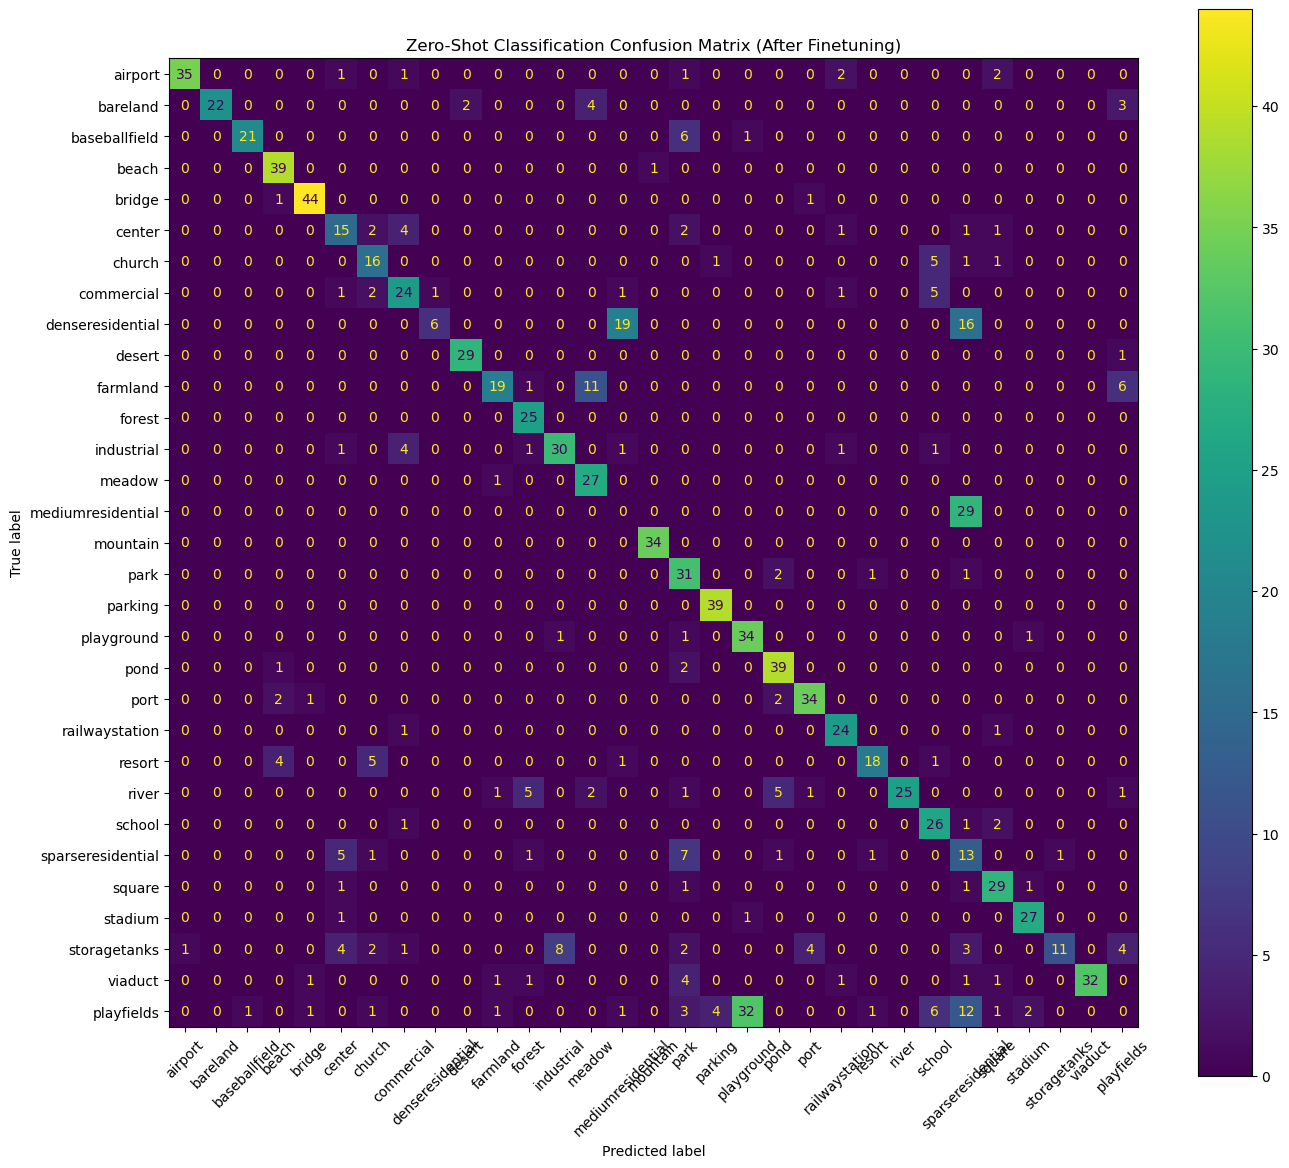

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

accuracy = accuracy_score(all_gt, all_preds)
f1 = f1_score(all_gt, all_preds, average='macro')

print(f"Zero-shot Accuracy after finetuning: {accuracy * 100:.2f}%")
print(f"Macro F1 Score after finetuning:     {f1:.4f}")

# Confusion matrix
cm = confusion_matrix(all_gt, all_preds, labels=classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)

fig, ax = plt.subplots(figsize=(14, 12))
disp.plot(ax=ax, xticks_rotation=45, colorbar=True)
plt.title("Zero-Shot Classification Confusion Matrix (After Finetuning)")
plt.tight_layout()
plt.savefig("confusion_matrix_finetuned.png", dpi=150)
plt.show()

In [ ]:
# Image to text retrieval

In [ ]:
class RSICD_RetrievalDataset(Dataset):
    def __init__(self, img_dir, json_path, preprocess, split='test'):
        self.img_dir = img_dir
        self.preprocess = preprocess
        self.data = []

        with open(json_path, 'r') as f:
            annotations = json.load(f)

        for item in annotations['images']:
            if item['split'] == split:
                captions = [c['raw'] for c in item['sentences']]
                self.data.append({
                    'image_path': os.path.join(img_dir, item['filename']),
                    'captions': captions
                })
        print(f"Loaded {len(self.data)} items for retrieval in split: {split}")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image = Image.open(item['image_path']).convert('RGB')
        image = self.preprocess(image)

        return {
            'image': image,
            'captions': item['captions']
        }

In [ ]:
retrieval_dataset = RSICD_RetrievalDataset(img_dir, json_dir, preprocess, split='test')

Loaded 1093 items for retrieval in split: test


In [ ]:
def image_to_text_retrieval(peft_model_semisup, test_dataset_with_captions, k_values = [1, 5, 10]):
    all_img_feats, all_txt_feats, img_to_caption_idx = [], [], {}
    caption_list = []

    peft_model_semisup.eval()
    with torch.no_grad():
        for idx, item in tqdm(enumerate(test_dataset_with_captions), total=len(test_dataset_with_captions), desc="Processing for retrieval"):
            img = item['image'].unsqueeze(0).to(device)
            img_feat = F.normalize(peft_model_semisup.encode_image(img), dim=-1)
            all_img_feats.append(img_feat.squeeze())

            start = len(caption_list)
            for cap in item['captions']:
                tokens = tokenizer(cap).to(device)
                txt_feat = F.normalize(peft_model_semisup.encode_text(tokens), dim=-1)
                all_txt_feats.append(txt_feat.squeeze())
                caption_list.append(cap)
            img_to_caption_idx[idx] = list(range(start, len(caption_list)))
    img_feats = torch.stack(all_img_feats)
    txt_feats = torch.stack(all_txt_feats)

    sim = img_feats @ txt_feats.T

    print("\n--- Image-to-Text Retrieval Results ---")
    for k in k_values:
        hits = 0
        for img_idx, gt_cap_idxs in img_to_caption_idx.items():
            top_k_indices = sim[img_idx].topk(k).indices.tolist()
            if any(cap_idx in gt_cap_idxs for cap_idx in top_k_indices):
                hits += 1
        recall = hits / len(img_to_caption_idx)
        print(f"Image-to-Text Recall@{k}: {recall:.4f}")

In [ ]:
image_to_text_retrieval(peft_model_semisup, retrieval_dataset)

Processing for retrieval:   0%|          | 0/1093 [00:00<?, ?it/s]


--- Image-to-Text Retrieval Results ---
Image-to-Text Recall@1: 0.0970
Image-to-Text Recall@5: 0.2123
Image-to-Text Recall@10: 0.3038


In [ ]:
# Text-to-image

In [ ]:
def text_to_image_retrieval(peft_model_semisup, test_dataset_with_captions, k_values=[1, 5, 10]):
    all_img_feats, all_txt_feats = [], []
    caption_to_img_idx = []

    peft_model_semisup.eval()
    with torch.no_grad():
        for img_idx, item in tqdm(enumerate(test_dataset_with_captions), total=len(test_dataset_with_captions), desc="Processing for text-to-image retrieval"):
            img = item['image'].unsqueeze(0).to(device)
            img_feat = F.normalize(peft_model_semisup.encode_image(img), dim=-1)
            all_img_feats.append(img_feat.squeeze())

            for cap in item['captions']:
                tokens = tokenizer(cap).to(device)
                txt_feat = F.normalize(peft_model_semisup.encode_text(tokens), dim=-1)
                all_txt_feats.append(txt_feat.squeeze())
                caption_to_img_idx.append(img_idx)

    img_feats = torch.stack(all_img_feats)
    txt_feats = torch.stack(all_txt_feats)

    sim = txt_feats @ img_feats.T

    print("\n--- Text-to-Image Retrieval Results ---")
    for k in k_values:
        hits = 0
        for txt_idx, gt_img_idx in enumerate(caption_to_img_idx):
            top_k_indices = sim[txt_idx].topk(k).indices.tolist()
            if gt_img_idx in top_k_indices:
                hits += 1
        recall = hits / len(caption_to_img_idx)
        print(f"Text-to-Image Recall@{k}: {recall:.4f}")


### Image-to-Text Retrieval Function (`image_to_text_retrieval`)

This function evaluates the model's ability to retrieve relevant captions given an image. It measures how often the correct caption (or one of the correct captions if multiple exist) is found within the top-K most similar captions for a given image.

**Inputs:**
-   `peft_model_semisup`: The fine-tuned CLIP model (or PEFT-adapted model).
-   `test_dataset_with_captions`: A dataset containing images and their associated ground-truth captions.
-   `k_values`: A list of integers (e.g., `[1, 5, 10]`) indicating the number of top predictions to consider for recall calculation.

**Process:**
1.  **Feature Extraction**: It iterates through the `test_dataset_with_captions`.
    -   For each image, it encodes the image using `peft_model_semisup.encode_image()` to get `img_feat`.
    -   For all captions associated with that image, it encodes each caption using `peft_model_semisup.encode_text()` to get `txt_feat`.
    -   All image features and text features are normalized.
    -   It builds a mapping (`img_to_caption_idx`) from image index to the indices of its corresponding captions in the overall `caption_list`.
2.  **Similarity Calculation**: After processing all images and captions, it computes a similarity matrix (`sim`) by performing a matrix multiplication between `img_feats` and the transpose of `txt_feats`. Each entry `sim[i, j]` represents the similarity between image `i` and caption `j`.
3.  **Recall@K Calculation**: For each `k` in `k_values`:
    -   For each image in the test set, it identifies the `k` captions with the highest similarity scores.
    -   It checks if any of the ground-truth captions for that image are present among these top `k` retrieved captions.
    -   `hits` count how many images successfully retrieve at least one of their correct captions.
    -   **Recall@K** is calculated as `hits / total_number_of_images`.

**Output**: Prints the Image-to-Text Recall@K for each specified `k_value`.

### Text-to-Image Retrieval Function (`text_to_image_retrieval`)

This function evaluates the model's ability to retrieve relevant images given a text query (caption). It measures how often the correct image is found within the top-K most similar images for a given caption.

**Inputs:**
-   `peft_model_semisup`: The fine-tuned CLIP model.
-   `test_dataset_with_captions`: A dataset containing images and their associated ground-truth captions.
-   `k_values`: A list of integers (e.g., `[1, 5, 10]`) indicating the number of top predictions to consider for recall calculation.

**Process:**
1.  **Feature Extraction**: It iterates through the `test_dataset_with_captions`.
    -   For each image, it encodes the image using `peft_model_semisup.encode_image()` to get `img_feat`.
    -   For each caption associated with an image, it encodes the caption using `peft_model_semisup.encode_text()` to get `txt_feat`.
    -   All image features and text features are normalized.
    -   It creates a list (`caption_to_img_idx`) that maps each processed caption's index to the index of its corresponding image.
2.  **Similarity Calculation**: It computes a similarity matrix (`sim`) by performing a matrix multiplication between `txt_feats` and the transpose of `img_feats`. Each entry `sim[i, j]` represents the similarity between caption `i` and image `j`.
3.  **Recall@K Calculation**: For each `k` in `k_values`:
    -   For each caption, it identifies the `k` images with the highest similarity scores.
    -   It checks if the ground-truth image for that caption is present among these top `k` retrieved images.
    -   `hits` count how many captions successfully retrieve their correct image.
    -   **Recall@K** is calculated as `hits / total_number_of_captions`.

**Output**: Prints the Text-to-Image Recall@K for each specified `k_value`.

In [ ]:
text_to_image_retrieval(peft_model_semisup, retrieval_dataset)

Processing for text-to-image retrieval:   0%|          | 0/1093 [00:00<?, ?it/s]


--- Text-to-Image Retrieval Results ---
Text-to-Image Recall@1: 0.0714
Text-to-Image Recall@5: 0.2474
Text-to-Image Recall@10: 0.3833


In [ ]:
# Leaderboard

In [ ]:
class LeaderboardDataset(Dataset):
    def __init__(self, img_dir, preprocess):
        self.img_dir = img_dir
        self.preprocess = preprocess
        self.image_filenames = [f for f in os.listdir(img_dir) if f.lower().endswith('.jpg',)]
        print(f"Found {len(self.image_filenames)} images in {img_dir}")
    def __len__(self):
        return len(self.image_filenames)
    def __getitem__(self, idx):
        filename = self.image_filenames[idx]
        img_path = os.path.join(self.img_dir, filename)
        image = Image.open(img_path).convert('RGB')
        image = self.preprocess(image)
        return image, filename

In [ ]:
leaderboard_img_dir = '/home/ehath390/Desktop/leaderboard_DL/'
leaderboard_dataset = LeaderboardDataset(leaderboard_img_dir, preprocess)
leaderboard_dataloader = DataLoader(leaderboard_dataset, batch_size=32, shuffle=False, num_workers=2)

Found 2100 images in /home/ehath390/Desktop/leaderboard_DL/


In [ ]:
classes = [
    "agricultural", "airplane", "baseballdiamond", "beach", "buildings",
    "chaparral", "denseresidential,", "forest", "freeway", "golfcourse",
    "harbor", "intersection", "mediumresidential", "mobilehomepark", "overpass",
    "parkinglot", "river", "runway", "sparseresidential", "storagetanks", "tenniscourt"
]

print(f"Found {len(classes)} classes: {classes}")

Found 21 classes: ['agricultural', 'airplane', 'baseballdiamond', 'beach', 'buildings', 'chaparral', 'denseresidential,', 'forest', 'freeway', 'golfcourse', 'harbor', 'intersection', 'mediumresidential', 'mobilehomepark', 'overpass', 'parkinglot', 'river', 'runway', 'sparseresidential', 'storagetanks', 'tenniscourt']


In [ ]:
peft_model_semisup.eval()

with torch.no_grad():
    class_embeddings = []
    for cls in classes:
        prompts = [t.format(cls) for t in templates]
        tokens = tokenizer(prompts).to(device)
        embs = peft_model_semisup.encode_text(tokens)
        embs = embs / embs.norm(dim=-1, keepdim=True)
        avg_emb = embs.mean(dim=0)
        avg_emb = avg_emb / avg_emb.norm()
        class_embeddings.append(avg_emb)

    class_embeddings = torch.stack(class_embeddings)
    print(f"Class embedding matrix: {class_embeddings.shape}")

Class embedding matrix: torch.Size([21, 512])


In [ ]:
leaderboard_preds = []
leaderboard_filenames = []

peft_model_semisup.eval()

with torch.no_grad():
    for images, filenames in tqdm(leaderboard_dataloader, desc="Predicting leaderboard images with updated classes"):
        images = images.to(device)

        image_features = peft_model_semisup.encode_image(images)
        image_features = image_features / image_features.norm(dim=-1, keepdim=True)

        similarity = image_features @ class_embeddings.T
        predictions = similarity.argmax(dim=-1)

        leaderboard_preds.extend([classes[p] for p in predictions.cpu()])
        leaderboard_filenames.extend(filenames)

print("Leaderboard prediction done with updated classes!")

Predicting leaderboard images with updated classes:   0%|          | 0/66 [00:00<?, ?it/s]

Leaderboard prediction done with updated classes!


In [ ]:
output_filename = 'predictions_final_unsup_model.txt'
with open(output_filename, 'w') as f:
    for fname, pred in zip(leaderboard_filenames, leaderboard_preds):
        f.write(f"{fname} {pred}\n")

print(f"Updated predictions saved to {output_filename}!")

Updated predictions saved to predictions_final_unsup_model.txt!
